In [39]:
import numpy as np
import pandas as pd
from sklearn import set_config
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_auc_score,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    brier_score_loss, f1_score
)
from sklearn.model_selection import cross_val_score
from sklearn.calibration import calibration_curve
from sklearn.base import clone
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score
from sklearn.neighbors import KNeighborsClassifier

In [41]:
# Load the data
with open("heart.csv", "r") as f:
    lines = [line.strip().strip('"') for line in f] 

rows = [line.split(",") for line in lines]
header = rows[0]
header[0] = header[0].lstrip('\ufeff')

data = pd.DataFrame(rows[1:], columns=rows[0])
data.columns.values[0] = 'Age'
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0,Up,0


In [43]:
#Pick target column and feature columns
target = "HeartDisease"
y = data[target].astype(int)

# numeric and categorical input columns
num_cols = ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]
cat_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
X = data[num_cols + cat_cols]

# Train/test split (stratified using target column)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=43
)


k_values = [i for i in range (1,31)]
scores = []

# Preprocess + Model Pipeline
# Need to standardize numeric features
# One hot encode categorical features
pre = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)    

In [45]:
# Tune the decision threshold using CV on the training set
# Using k-fold validation on the training set
# for each fold we predict on the validation set

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=88)

for k in k_values:
    pipeline = Pipeline(steps=[
        ('preprocessor', pre),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])

    fold_f1 = []

    for tr_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        pipeline.fit(X_tr, y_tr)
        y_val_pred = pipeline.predict(X_val)

        f1 = f1_score(y_val, y_val_pred)
        fold_f1.append(f1)

    avg_f1 = np.mean(fold_f1)
    scores.append(avg_f1)
    print(f"k={k}: Mean CV F1 Score = {avg_f1:.4f}")

# Find best k
best_k = k_values[np.argmax(scores)]
print(f"\n Best k based on CV F1 score: {best_k} (F1 = {max(scores):.4f})")


k=1: Mean CV F1 Score = 0.8387
k=2: Mean CV F1 Score = 0.8145
k=3: Mean CV F1 Score = 0.8704
k=4: Mean CV F1 Score = 0.8472
k=5: Mean CV F1 Score = 0.8703
k=6: Mean CV F1 Score = 0.8544
k=7: Mean CV F1 Score = 0.8779
k=8: Mean CV F1 Score = 0.8688
k=9: Mean CV F1 Score = 0.8808
k=10: Mean CV F1 Score = 0.8677
k=11: Mean CV F1 Score = 0.8732
k=12: Mean CV F1 Score = 0.8686
k=13: Mean CV F1 Score = 0.8772
k=14: Mean CV F1 Score = 0.8699
k=15: Mean CV F1 Score = 0.8747
k=16: Mean CV F1 Score = 0.8692
k=17: Mean CV F1 Score = 0.8709
k=18: Mean CV F1 Score = 0.8618
k=19: Mean CV F1 Score = 0.8694
k=20: Mean CV F1 Score = 0.8648
k=21: Mean CV F1 Score = 0.8686
k=22: Mean CV F1 Score = 0.8673
k=23: Mean CV F1 Score = 0.8695
k=24: Mean CV F1 Score = 0.8654
k=25: Mean CV F1 Score = 0.8739
k=26: Mean CV F1 Score = 0.8683
k=27: Mean CV F1 Score = 0.8767
k=28: Mean CV F1 Score = 0.8731
k=29: Mean CV F1 Score = 0.8736
k=30: Mean CV F1 Score = 0.8730

 Best k based on CV F1 score: 9 (F1 = 0.8808)


In [47]:
pipeline = Pipeline(steps=[
        ('preprocessor', pre),
        ('knn', KNeighborsClassifier(n_neighbors=best_k))
    ])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

In [49]:
print("k:", best_k)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

k: 9
Accuracy: 0.8913043478260869
ROC-AUC: 0.9368932038834952

Confusion Matrix:
 [[ 88  15]
 [ 10 117]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.85      0.88       103
           1       0.89      0.92      0.90       127

    accuracy                           0.89       230
   macro avg       0.89      0.89      0.89       230
weighted avg       0.89      0.89      0.89       230



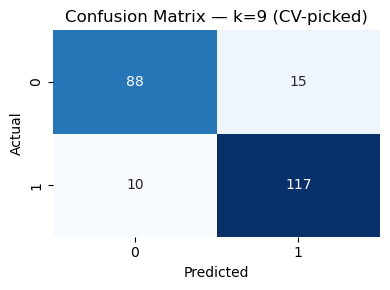

In [51]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title(f"Confusion Matrix — k={best_k} (CV-picked)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()

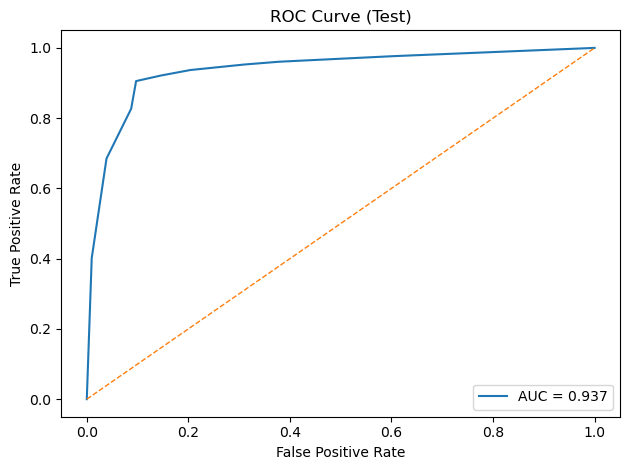

In [53]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "--", linewidth=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test)")
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

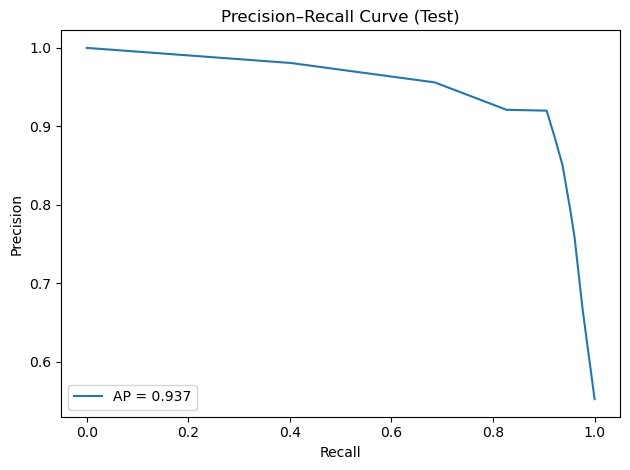

In [55]:
# Precision–Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
plt.figure()
plt.plot(rec, prec, label=f"AP = {ap:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Test)")
plt.legend(loc="lower left"); plt.tight_layout(); plt.show()

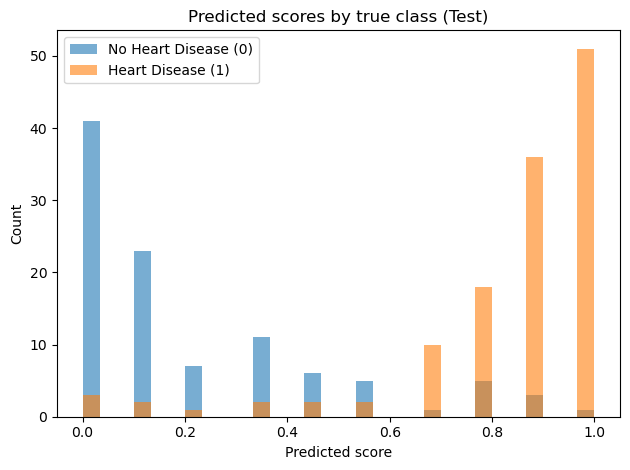

In [57]:
# Score distribution by class
plt.figure()
plt.hist(y_prob[y_test == 0], bins=30, alpha=0.6, label="No Heart Disease (0)")
plt.hist(y_prob[y_test == 1], bins=30, alpha=0.6, label="Heart Disease (1)")
plt.xlabel("Predicted score"); plt.ylabel("Count")
plt.title("Predicted scores by true class (Test)")
plt.legend(); plt.tight_layout(); plt.show()

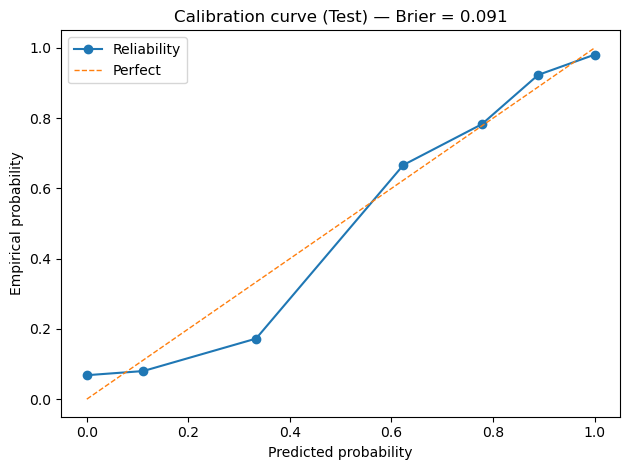

In [59]:
# Calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy="quantile")
brier = brier_score_loss(y_test, y_prob)
plt.figure()
plt.plot(prob_pred, prob_true, marker="o", label="Reliability")
plt.plot([0, 1], [0, 1], "--", linewidth=1, label="Perfect")
plt.xlabel("Predicted probability"); plt.ylabel("Empirical probability")
plt.title(f"Calibration curve (Test) — Brier = {brier:.3f}")
plt.legend(); plt.tight_layout(); plt.show()

Text(0, 0.5, 'Accuracy Score')

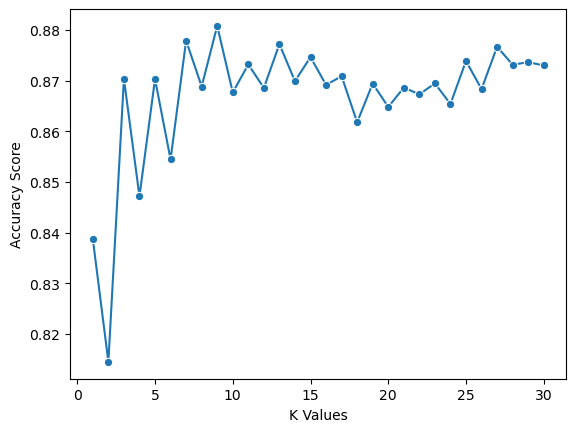

In [61]:
sns.lineplot(x = k_values, y = scores, marker = 'o')
plt.xlabel("K Values")
plt.ylabel("Accuracy Score")